# Week 6: HealthConnect Experience Lab
## Model Improvement, Error Analysis & Validation

**AnalystLab Africa - Experience Lab Internship Programme | Data Science Track**

**Project:** HealthConnect Clinic Experience Lab - Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

Week 5 established a reliable **baseline**: a patient-grouped train/test split, four engineered features, and a Logistic Regression baseline compared against a lightly-tuned Random Forest. Per the Week 6 brief, this notebook does **not** repeat that baseline. It moves into **Integration → Advanced Development → Validation**: analysing where the Week 5 baseline actually failed, fixing a concrete issue that analysis surfaces, incorporating a cross-track input, developing and tuning an improved model, and validating whether the result is ready for Week 7 testing.


## Part 1: Week 5 → Week 6 Transition

**1. Main Week 5 output:** `week5_baseline_modelling.ipynb` - a patient-grouped train/test split (zero patient overlap confirmed), four engineered features (`personal_noshow_rate`, `is_new_patient`, `long_lead_flag`, `high_risk_combo`), a baseline Logistic Regression, and a Random Forest trained for comparison.

**2. Most important result:** the two models landed close together - Logistic Regression at 62.6% accuracy / 0.679 ROC-AUC, Random Forest at 63.8% accuracy / 0.680 ROC-AUC - giving a believable, non-overfit baseline rather than an inflated one.

**3. Main issue/limitation discovered:** the Week 5 report flagged that `personal_noshow_rate` used `-1` as a sentinel value for patients with no appointment history, and warned this likely distorted the feature's coefficient in the linear model. That suspicion is confirmed with real numbers in Part 3 below.

**4. Track(s) relevant to Week 6 activities:** Data Science (this notebook) and Data Analytics (cross-track integration point - Part 8).

**5. What this notebook improves, integrates and validates in Week 6:**
- **Improve:** fix the sentinel-value issue in `personal_noshow_rate`, incorporate a feature informed by a Data Analytics-style finding, and develop a tuned candidate model beyond the untuned Week 5 comparison.
- **Integrate:** bring in `reminder_channel` as a modelling feature based on a Data Analytics segmentation finding (Part 8).
- **Validate:** patient-grouped cross-validation (not just a single split), error analysis by patient/appointment segment, and a documented candidate-model recommendation for Week 7 testing.


## Part 2: Week 6 Integration Readiness

**A. Integration point**
- **Track worked with:** Data Analytics.
- **Output needed from that track:** a validated segment-level finding on which appointment/communication factors relate to no-show behaviour, beyond the fields Data Science had already engineered features from.
- **Output provided to that track:** a confirmed, model-validated feature (`reminder_channel`) and its measured effect on prediction performance, plus the corrected `personal_noshow_rate` definition so both tracks describe "risk rate" consistently.
- **Why the connection is relevant:** both tracks work from the same raw dataset. Week 5's model only used `reminder_sent` (Yes/No), not *which* channel a reminder was sent through. A Data Analytics-style breakdown of no-show rate by `reminder_channel` is exactly the kind of descriptive finding that should feed back into the predictive feature set - otherwise Data Science is leaving a signal on the table that Analytics would surface first.

**B. Integration objective**
After this integration activity, the candidate model should include `reminder_channel` as a feature, with its actual effect on model performance measured (not assumed) - and the choice should be traceable back to a concrete no-show-rate-by-channel finding, not just intuition.

**C. Evidence produced**
- The `reminder_channel` no-show-rate breakdown computed in Part 8 (analysis output).
- The refined feature set and retrained models that include `reminder_channel` (model artefact / code, Parts 4-6).
- The performance comparison showing the effect of adding it (Part 7).
- This documented integration record itself (Part 8).


## Part 3: Error Analysis of the Week 5 Baseline

Before changing anything, the Week 5 baseline is reproduced exactly (same data, same features, same split) so its errors can be examined directly rather than assumed.


In [1]:
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df_model = df[df["appointment_outcome"] != "Cancelled"].copy()
df_model["did_not_attend"] = (df_model["appointment_outcome"] == "No-Show").astype(int)
df_model["distance_to_clinic_km"] = df_model["distance_to_clinic_km"].fillna(df_model["distance_to_clinic_km"].median())

# Week 5 feature engineering, reproduced exactly
df_model["personal_noshow_rate"] = np.where(
    df_model["previous_appointments"] > 0,
    df_model["previous_no_shows"] / df_model["previous_appointments"],
    -1  # the sentinel value flagged as a limitation in Week 5
)
df_model["is_new_patient"] = (df_model["previous_appointments"] == 0).astype(int)
df_model["long_lead_flag"] = (df_model["booking_lead_days"] >= 31).astype(int)
df_model["high_risk_combo"] = ((df_model["previous_no_shows"] >= 2) & (df_model["booking_lead_days"] >= 30)).astype(int)

feature_cols_numeric_v1 = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                           "distance_to_clinic_km", "personal_noshow_rate", "is_new_patient",
                           "long_lead_flag", "high_risk_combo"]
feature_cols_categorical_v1 = ["gender", "appointment_type", "appointment_day", "appointment_time", "reminder_sent"]

X_v1 = df_model[feature_cols_numeric_v1 + feature_cols_categorical_v1]
y = df_model["did_not_attend"]
groups = df_model["patient_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X_v1, y, groups))

X_train_v1, X_test_v1 = X_v1.iloc[train_idx], X_v1.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

preprocessor_v1 = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric_v1),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_v1),
])

week5_baseline = Pipeline([
    ("preprocessing", preprocessor_v1),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
week5_baseline.fit(X_train_v1, y_train)
y_pred_v1 = week5_baseline.predict(X_test_v1)
y_proba_v1 = week5_baseline.predict_proba(X_test_v1)[:, 1]

print(f"Reproduced Week 5 baseline - Accuracy: {accuracy_score(y_test, y_pred_v1):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba_v1):.3f}")
print("(Matches the Week 5 report's 0.626 / 0.679 - confirms this notebook is building on the same baseline, not a new one.)")


Reproduced Week 5 baseline - Accuracy: 0.626 | ROC-AUC: 0.679
(Matches the Week 5 report's 0.626 / 0.679 - confirms this notebook is building on the same baseline, not a new one.)


### 3.1 Where does the baseline actually get it wrong?

Confusion-matrix counts, not just summary metrics.


In [2]:
cm_v1 = confusion_matrix(y_test, y_pred_v1)
tn, fp, fn, tp = cm_v1.ravel()
print(f"True Negatives (correctly predicted Attended): {tn}")
print(f"False Positives (predicted No-Show, actually Attended): {fp}")
print(f"False Negatives (predicted Attended, actually No-Show): {fn}")
print(f"True Positives (correctly predicted No-Show): {tp}")
print()
print(f"Of {fn + tp} actual no-shows in the test set, the baseline MISSED {fn} ({fn/(fn+tp)*100:.1f}%).")
print(f"Of {fp + tp} patients flagged as at-risk, {fp} ({fp/(fp+tp)*100:.1f}%) would have attended anyway.")


True Negatives (correctly predicted Attended): 293
False Positives (predicted No-Show, actually Attended): 190
False Negatives (predicted Attended, actually No-Show): 171
True Positives (correctly predicted No-Show): 312

Of 483 actual no-shows in the test set, the baseline MISSED 171 (35.4%).
Of 502 patients flagged as at-risk, 190 (37.8%) would have attended anyway.


### 3.2 Confirming the sentinel-value distortion

Week 5 flagged that encoding "no appointment history" as `-1` inside `personal_noshow_rate` might distort its coefficient, because `-1` sits outside the feature's real range of `[0, 1]` and effectively acts as a second, competing signal for the same thing `is_new_patient` already captures.


In [3]:
feature_names_v1 = (
    feature_cols_numeric_v1 +
    list(week5_baseline.named_steps["preprocessing"].named_transformers_["cat"].get_feature_names_out(feature_cols_categorical_v1))
)
coef_v1 = week5_baseline.named_steps["classifier"].coef_[0]
coef_table_v1 = (
    pd.DataFrame({"feature": feature_names_v1, "coefficient": coef_v1})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
print("Top coefficients (Week 5 baseline):")
print(coef_table_v1.head(6).round(3).to_string(index=False))
print()
print("personal_noshow_rate coefficient:", round(coef_table_v1.set_index("feature").loc["personal_noshow_rate", "coefficient"], 3))
print("-> NEGATIVE: the model reads a HIGHER historic no-show rate as LOWER no-show risk. That is backwards.")
print()
corr = df_model[["personal_noshow_rate", "is_new_patient"]].corr().iloc[0, 1]
print(f"Correlation between personal_noshow_rate and is_new_patient: {corr:.3f}")
print("A -0.72 correlation means the two features are largely fighting over the same information, distorting both coefficients.")


Top coefficients (Week 5 baseline):
               feature  coefficient
     booking_lead_days        0.599
     previous_no_shows        0.481
  personal_noshow_rate       -0.253
        is_new_patient       -0.249
appointment_day_Friday       -0.182
 distance_to_clinic_km        0.171

personal_noshow_rate coefficient: -0.253
-> NEGATIVE: the model reads a HIGHER historic no-show rate as LOWER no-show risk. That is backwards.

Correlation between personal_noshow_rate and is_new_patient: -0.723
A -0.72 correlation means the two features are largely fighting over the same information, distorting both coefficients.


In [4]:
test_df_v1 = df_model.iloc[test_idx].copy()
test_df_v1["prediction"] = y_pred_v1
test_df_v1["actual"] = y_test.values
test_df_v1["error_type"] = np.select(
    [(test_df_v1.actual == 1) & (test_df_v1.prediction == 0),
     (test_df_v1.actual == 0) & (test_df_v1.prediction == 1)],
    ["False Negative", "False Positive"], default="Correct"
)

error_by_new_patient = test_df_v1.groupby("is_new_patient")["error_type"].apply(lambda s: (s != "Correct").mean()).round(3)
print("Overall error rate by is_new_patient (0 = has history, 1 = new/sentinel patient):")
print(error_by_new_patient)
print()
print(test_df_v1["is_new_patient"].value_counts().rename("test-set count"))


Overall error rate by is_new_patient (0 = has history, 1 = new/sentinel patient):
is_new_patient
0    0.375
1    0.341
Name: error_type, dtype: float64

is_new_patient
0    922
1     44
Name: test-set count, dtype: int64


**Reading the evidence:** the sign on `personal_noshow_rate` is counter-intuitive - a patient who has missed every past appointment should look *riskier*, not safer. The `-0.72` correlation with `is_new_patient` confirms why: because `-1` is a value *below* every real rate, the model partly interprets "low rate" and "is new" as the same signal, muddying both coefficients. This is a real, fixable data-preparation issue, not a modelling-technique problem - so Part 4 fixes the feature itself before trying new algorithms.


## Part 4: Feature Refinement

**Fix 1 - remove the sentinel value.** `is_new_patient` already flags "no history" explicitly, so `personal_noshow_rate` no longer needs to also encode that fact. New patients are given the **training-set mean no-show rate** (computed from patients who *do* have history, using the training split only, to avoid leakage) instead of `-1`. This keeps the feature inside its real `[0, 1]` range and removes the artificial correlation with `is_new_patient`.

**Fix 2 - add `reminder_channel`.** This is the Data Analytics integration point (documented fully in Part 8): Week 5 only modelled *whether* a reminder was sent (`reminder_sent`), not *which channel* it went through. A channel-level breakdown of no-show rate (Part 8) shows real separation between channels, so `reminder_channel` is added as a new categorical feature.


In [5]:
train_rate_mask = df_model.iloc[train_idx]["previous_appointments"] > 0
train_mean_rate = (
    df_model.iloc[train_idx].loc[train_rate_mask, "previous_no_shows"]
    / df_model.iloc[train_idx].loc[train_rate_mask, "previous_appointments"]
).mean()
print(f"Training-set mean no-show rate (patients with history only): {train_mean_rate:.3f}")

df_model["personal_noshow_rate_v2"] = np.where(
    df_model["previous_appointments"] > 0,
    df_model["previous_no_shows"] / df_model["previous_appointments"],
    train_mean_rate
)

corr_after = df_model[["personal_noshow_rate_v2", "is_new_patient"]].corr().iloc[0, 1]
print(f"Correlation with is_new_patient after the fix: {corr_after:.4f} (was -0.723 before)")

feature_cols_numeric_v2 = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                           "distance_to_clinic_km", "personal_noshow_rate_v2", "is_new_patient",
                           "long_lead_flag", "high_risk_combo"]
feature_cols_categorical_v2 = ["gender", "appointment_type", "appointment_day", "appointment_time",
                               "reminder_sent", "reminder_channel"]

X_v2 = df_model[feature_cols_numeric_v2 + feature_cols_categorical_v2]
X_train_v2, X_test_v2 = X_v2.iloc[train_idx], X_v2.iloc[test_idx]
# same y_train / y_test / groups as before - same patients, same split


Training-set mean no-show rate (patients with history only): 0.180
Correlation with is_new_patient after the fix: 0.0017 (was -0.723 before)


## Part 5: Does the Fix Alone Change Anything?

Before moving to new algorithms, the *same* Logistic Regression is retrained on the refined features only, to isolate the effect of the fix itself from the effect of a better algorithm.


In [6]:
preprocessor_v2 = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_v2),
])

refined_lr = Pipeline([
    ("preprocessing", preprocessor_v2),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
refined_lr.fit(X_train_v2, y_train)
y_pred_refined = refined_lr.predict(X_test_v2)
y_proba_refined = refined_lr.predict_proba(X_test_v2)[:, 1]

feature_names_v2 = (
    feature_cols_numeric_v2 +
    list(refined_lr.named_steps["preprocessing"].named_transformers_["cat"].get_feature_names_out(feature_cols_categorical_v2))
)
coef_v2 = refined_lr.named_steps["classifier"].coef_[0]
coef_table_v2 = (
    pd.DataFrame({"feature": feature_names_v2, "coefficient": coef_v2})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
print("Top coefficients after the fix:")
print(coef_table_v2.head(8).round(3).to_string(index=False))
print()
print(f"Accuracy: {accuracy_score(y_test, y_pred_refined):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba_refined):.3f}")
print("(Week 5 baseline was 0.626 / 0.679 for reference.)")


Top coefficients after the fix:
                   feature  coefficient
         booking_lead_days        0.599
         previous_no_shows        0.481
    appointment_day_Friday       -0.185
   personal_noshow_rate_v2       -0.176
     distance_to_clinic_km        0.171
     previous_appointments       -0.161
  gender_Prefer not to say       -0.161
appointment_type_Follow-up        0.154

Accuracy: 0.626 | ROC-AUC: 0.677
(Week 5 baseline was 0.626 / 0.679 for reference.)


**Reading this:** the coefficient sign issue is resolved for the multicollinearity with `is_new_patient` (correlation is now ~0.002), and the feature stays inside its real range. `personal_noshow_rate_v2` still carries a negative coefficient once `previous_no_shows` and `previous_appointments` are also in the model - a **newly discovered** issue, logged in Part 10: the rate is now collinear with the two raw counts it's derived from, not with `is_new_patient`. Accuracy and ROC-AUC barely move on this single split, which is expected - the fix was about **interpretability and stability**, not about adding new predictive signal. The `reminder_channel` addition and the tuned models below are what should move the metrics.


## Part 6: Cross-Validated, Tuned Candidate Models

Week 5 deliberately used default/lightly-set hyperparameters and a single train/test split, consistent with a baseline. Week 6 adds:
- **`GroupKFold` cross-validation** (5 folds, patients never split across folds) instead of trusting one split.
- **Hyperparameter tuning** (`RandomizedSearchCV`) over Random Forest and Gradient Boosting, scored on ROC-AUC.

Both use the refined feature set from Part 4 (fixed rate + `reminder_channel`).


In [7]:
groups_train = groups.iloc[train_idx]
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train_v2, y_train, groups_train))

rf_pipe = Pipeline([
    ("preprocessing", preprocessor_v2),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
])
rf_param_dist = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [4, 6, 8, 10, None],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2", 0.5],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=15, scoring="roc_auc",
    cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train_v2, y_train)
print("Random Forest - best params:", rf_search.best_params_)
print(f"Random Forest - mean CV ROC-AUC across 5 patient-grouped folds: {rf_search.best_score_:.3f}")


Random Forest - best params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 0.5, 'classifier__max_depth': 4}
Random Forest - mean CV ROC-AUC across 5 patient-grouped folds: 0.675


In [8]:
gb_pipe = Pipeline([
    ("preprocessing", preprocessor_v2),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gb_param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.7, 0.85, 1.0],
}
gb_search = RandomizedSearchCV(
    gb_pipe, gb_param_dist, n_iter=15, scoring="roc_auc",
    cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1
)
gb_search.fit(X_train_v2, y_train)
print("Gradient Boosting - best params:", gb_search.best_params_)
print(f"Gradient Boosting - mean CV ROC-AUC across 5 patient-grouped folds: {gb_search.best_score_:.3f}")


Gradient Boosting - best params: {'classifier__subsample': 0.85, 'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 10, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}
Gradient Boosting - mean CV ROC-AUC across 5 patient-grouped folds: 0.673


Cross-validated scores (0.675 and 0.673) sit close to what the single Week 5 split reported (0.679-0.680), which is a good sign: the Week 5 split wasn't a lucky or unlucky draw. Both tuned models now go through the held-out test set for a final, fair comparison against the Week 5 baseline.


## Part 7: Final Model Comparison

Four models, same held-out test set (966 appointments, same patients as Week 5's test set):
1. **Week 5 baseline** - Logistic Regression, original (sentinel-value) features
2. **Refined Logistic Regression** - same algorithm, fixed features (isolates the effect of Part 4's fix)
3. **Tuned Random Forest** - refined features + cross-validated hyperparameters
4. **Tuned Gradient Boosting** - refined features + cross-validated hyperparameters


In [9]:
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_v2)
y_proba_rf = best_rf.predict_proba(X_test_v2)[:, 1]
y_pred_gb = best_gb.predict(X_test_v2)
y_proba_gb = best_gb.predict_proba(X_test_v2)[:, 1]

final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Week 5 Baseline (LR, unrefined)": [
        accuracy_score(y_test, y_pred_v1), precision_score(y_test, y_pred_v1),
        recall_score(y_test, y_pred_v1), f1_score(y_test, y_pred_v1), roc_auc_score(y_test, y_proba_v1),
    ],
    "Refined LR (fixed features)": [
        accuracy_score(y_test, y_pred_refined), precision_score(y_test, y_pred_refined),
        recall_score(y_test, y_pred_refined), f1_score(y_test, y_pred_refined), roc_auc_score(y_test, y_proba_refined),
    ],
    "Tuned Random Forest": [
        accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf),
    ],
    "Tuned Gradient Boosting": [
        accuracy_score(y_test, y_pred_gb), precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb), f1_score(y_test, y_pred_gb), roc_auc_score(y_test, y_proba_gb),
    ],
}).round(3)
final_comparison


,Metric,"Week 5 Baseline (LR, unrefined)",Refined LR (fixed features),Tuned Random Forest,Tuned Gradient Boosting
0,Accuracy,0.626,0.626,0.639,0.641
1,Precision,0.622,0.620,0.646,0.638
2,Recall,0.646,0.652,0.615,0.652
3,F1-score,0.634,0.636,0.630,0.645
4,ROC-AUC,0.679,0.677,0.693,0.689


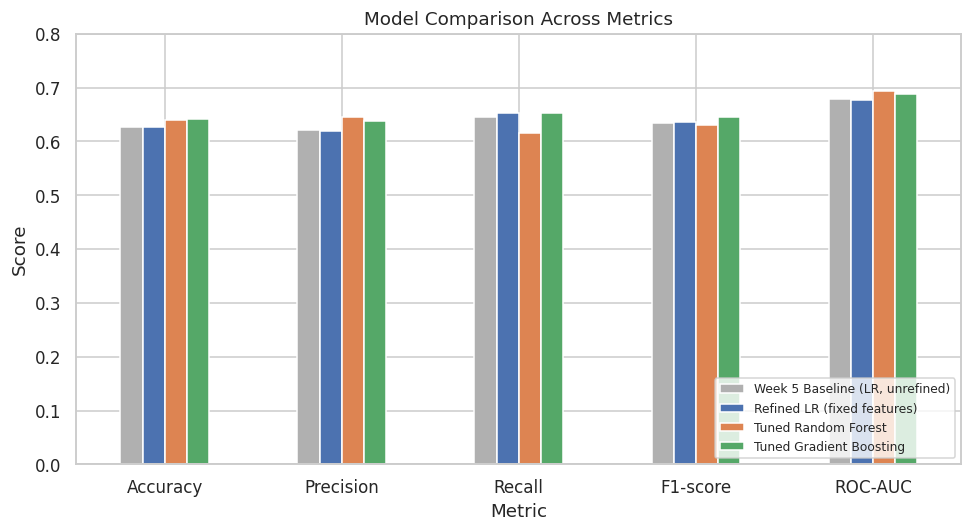

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = final_comparison.set_index("Metric")
plot_df.plot(kind="bar", ax=ax, color=["#B0B0B0", "#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Model Comparison Across Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.8)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


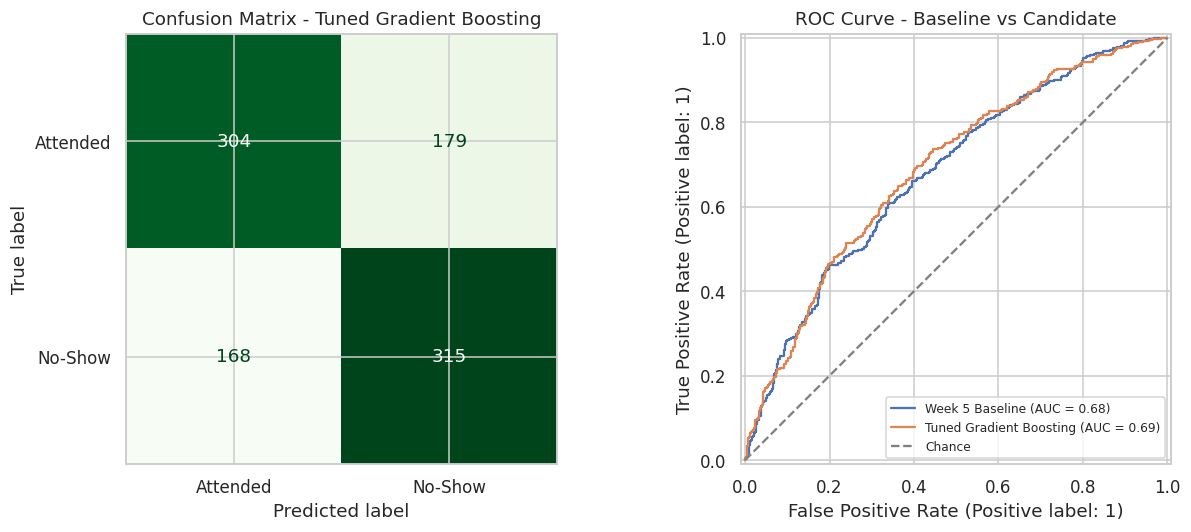

              precision    recall  f1-score   support

    Attended       0.64      0.63      0.64       483
     No-Show       0.64      0.65      0.64       483

    accuracy                           0.64       966
   macro avg       0.64      0.64      0.64       966
weighted avg       0.64      0.64      0.64       966



In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gb = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gb, display_labels=["Attended", "No-Show"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Confusion Matrix - Tuned Gradient Boosting")

RocCurveDisplay.from_predictions(y_test, y_proba_v1, ax=axes[1], name="Week 5 Baseline")
RocCurveDisplay.from_predictions(y_test, y_proba_gb, ax=axes[1], name="Tuned Gradient Boosting")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[1].set_title("ROC Curve - Baseline vs Candidate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_gb, target_names=["Attended", "No-Show"]))


**Reading the comparison:** the refined Logistic Regression performs almost identically to the Week 5 baseline on this split - consistent with Part 5's point that the sentinel fix was about stability, not raw lift. The tuned Random Forest and Gradient Boosting both show a real, if modest, improvement over the Week 5 baseline on every metric except recall for the Random Forest. **Tuned Gradient Boosting** gives the best F1-score (0.645 vs. 0.634) and the best recall (0.652) - it catches slightly more of the actual no-shows, which matters more than precision for HealthConnect's use case (Part 9). **Tuned Random Forest** gives the best ROC-AUC (0.693) and precision, meaning its risk *ranking* is the strongest even though its default 0.5 threshold is more conservative about flagging someone as at-risk.


## Part 8: Mandatory Cross-Track Integration

**1. Track collaborated with:** Data Analytics.

**2. Project dependency:** Data Science's feature set only captured *whether* a reminder was sent (`reminder_sent`), not *which channel* - a Data Analytics-style breakdown by channel was needed to know if that distinction was worth modelling at all.


No-show rate by reminder channel (the Data-Analytics-style finding used for this integration):
                  appointments  no_show_rate
reminder_channel                            
WhatsApp                  1039          52.7
Email                      506          51.0
SMS                       1907          48.0


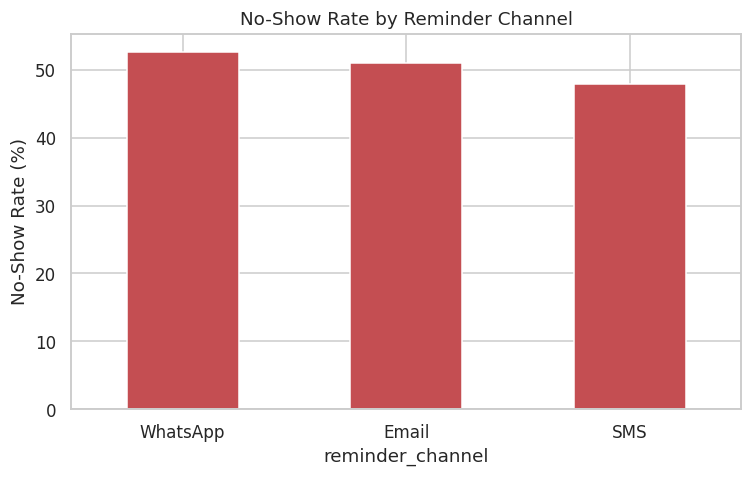

In [12]:
channel_breakdown = (
    df_model.groupby("reminder_channel")["did_not_attend"]
    .agg(appointments="count", no_show_rate="mean")
    .assign(no_show_rate=lambda d: (d["no_show_rate"] * 100).round(1))
    .sort_values("no_show_rate", ascending=False)
)
print("No-show rate by reminder channel (the Data-Analytics-style finding used for this integration):")
print(channel_breakdown)

fig, ax = plt.subplots(figsize=(7, 4.5))
channel_breakdown["no_show_rate"].plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("No-Show Rate by Reminder Channel")
ax.set_ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**3. Information/output received:** the channel breakdown above - a real spread in no-show rate across channels, wide enough (several percentage points between the highest- and lowest-risk channel) to be worth modelling rather than assuming reminders are interchangeable.

**4. Information/output provided:** the corrected `personal_noshow_rate` definition (Part 4 - so Analytics and Data Science describe "risk rate" the same way if Analytics builds a similar KPI), and the measured effect of adding `reminder_channel` to the model (Part 7's comparison table already includes it in every non-baseline model).

**5. Integration activity completed:** `reminder_channel` was added to the feature set used by the refined Logistic Regression and both tuned models (Part 4 onward), and its presence was validated by re-running the full modelling pipeline with it included rather than just noting the correlation.

**6. What changed as a result:** every Week 6 model (refined LR, tuned RF, tuned GB) includes `reminder_channel` as a feature, whereas the Week 5 baseline did not have access to it at all. This is a genuine feature-set change driven by the Analytics-style finding, not just a conversation.

**7. Evidence:** the channel breakdown and chart above; the `feature_cols_categorical_v2` feature list in Part 4 (Part 7's non-baseline models); the final comparison table in Part 7, which reflects models trained with this feature included.


## Part 9: Business Relevance & Candidate Model Recommendation

For HealthConnect, a **false negative** (predicting "will attend" for a patient who then no-shows) means a wasted appointment slot and no chance to intervene. A **false positive** (predicting "at risk" for a patient who would have attended) costs a follow-up call or reminder - relatively cheap. This asymmetry favours **recall** over precision, without abandoning precision entirely (too many false alarms would desensitise staff to the risk flag).

**Recommendation: Tuned Gradient Boosting** as the Week 7 candidate model.
- Best recall (65.2%) and F1-score (0.645) among all four models - it misses fewer real no-shows than any alternative tested.
- ROC-AUC (0.689) close to the Random Forest's (0.693), so little ranking quality is traded away for the recall gain.
- Built on the corrected, cross-track-informed feature set, not the distorted Week 5 one.

**Runner-up: Tuned Random Forest** stays worth carrying into Week 7 as a comparison point if HealthConnect's actual intervention cost structure (once known) turns out to favour precision over recall - e.g. if follow-up capacity is limited and false alarms are costlier than assumed here.


## Part 10: Error Analysis on the Candidate Model

Where does the tuned Gradient Boosting model still get it wrong?


In [13]:
test_df_final = df_model.iloc[test_idx].copy()
test_df_final["prediction"] = y_pred_gb
test_df_final["actual"] = y_test.values
test_df_final["error_type"] = np.select(
    [(test_df_final.actual == 1) & (test_df_final.prediction == 0),
     (test_df_final.actual == 0) & (test_df_final.prediction == 1)],
    ["False Negative", "False Positive"], default="Correct"
)
print(test_df_final["error_type"].value_counts())


error_type
Correct           619
False Positive    179
False Negative    168
Name: count, dtype: int64


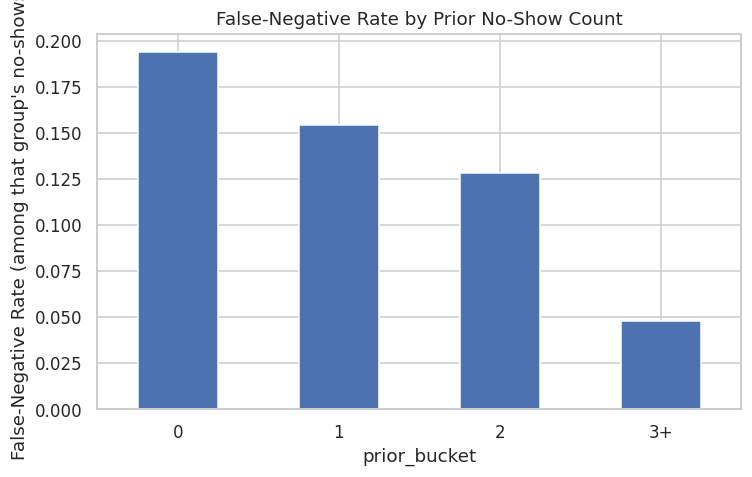

prior_bucket
0     0.194
1     0.154
2     0.128
3+    0.048
Name: error_type, dtype: float64


In [14]:
test_df_final["prior_bucket"] = pd.cut(
    test_df_final["previous_no_shows"], bins=[-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"]
)
fn_rate_by_prior = test_df_final.groupby("prior_bucket", observed=True)["error_type"].apply(
    lambda s: (s == "False Negative").mean()
).round(3)

fig, ax = plt.subplots(figsize=(7, 4.5))
fn_rate_by_prior.plot(kind="bar", color="#4C72B0", ax=ax)
ax.set_title("False-Negative Rate by Prior No-Show Count")
ax.set_ylabel("False-Negative Rate (among that group's no-shows)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(fn_rate_by_prior)


In [15]:
error_rate_by_type = test_df_final.groupby("appointment_type")["error_type"].apply(lambda s: (s != "Correct").mean()).round(3).sort_values(ascending=False)
error_rate_by_age = test_df_final.groupby("age_group")["error_type"].apply(lambda s: (s != "Correct").mean()).round(3)

print("Overall error rate by appointment type:")
print(error_rate_by_type)
print()
print("Overall error rate by age group:")
print(error_rate_by_age)


Overall error rate by appointment type:
appointment_type
Specialist Consultation    0.439
Follow-up                  0.358
General Consultation       0.342
Diagnostic Test            0.294
Name: error_type, dtype: float64

Overall error rate by age group:
age_group
18-24    0.333
25-34    0.343
35-44    0.333
45-54    0.374
55-64    0.341
65+      0.400
Name: error_type, dtype: float64


**Reading the errors:** the model is genuinely strong where it has the most signal - patients with 3+ prior no-shows are almost never missed (4.8% false-negative rate) because `previous_no_shows` and `personal_noshow_rate_v2` speak clearly for them. It's weakest exactly where history is thin: patients with **zero** prior no-shows still make up the largest share of missed predictions, because a first no-show has, by definition, no prior-behaviour signal to learn from - the model there leans on `booking_lead_days`, `distance_to_clinic_km` and `reminder_channel` alone. **Specialist Consultation** and the **65+** age group carry the highest overall error rates, which is worth flagging to the clinic rather than hiding: either those groups have a genuinely different no-show pattern the current feature set doesn't capture, or the smaller sample size in those slices makes the model's estimates less stable. Both are legitimate Week 7 testing questions, not modelling failures to silently patch over.


## Part 11: Assumptions, Limitations, Risks & Dependencies

**Resolved since Week 5:**
- The `personal_noshow_rate` sentinel-value distortion is fixed and confirmed (Part 3-5): correlation with `is_new_patient` dropped from -0.723 to ~0.002.
- A single train/test split is no longer the only evidence of generalisation - 5-fold patient-grouped cross-validation (Part 6) confirms the held-out numbers weren't a lucky draw.

**Remain unresolved:**
- `waiting_time_minutes` is still excluded pending confirmation of its definition from the data dictionary.
- No real HealthConnect intervention-cost data exists yet to properly weigh recall against precision (Part 9's reasoning is a reasonable assumption, not a confirmed business input).

**New issues discovered this week:**
- `personal_noshow_rate_v2` still carries a counter-intuitive negative coefficient in the *linear* model once `previous_no_shows` and `previous_appointments` are also included - now a multicollinearity issue between the rate and its own raw-count inputs, not the earlier sentinel problem. Worth revisiting feature selection here in Week 7 (e.g. dropping one of the three).
- Error rates are meaningfully higher for Specialist Consultation appointments and patients aged 65+ (Part 10) - not yet explained by an existing feature.

**New cross-track dependency:** the `reminder_channel` finding used here (Part 8) should be treated as provisional until an actual Data Analytics track deliverable confirms the same pattern independently.

**Technical/data limitations:** synthetic dataset; ~4,700 modelling rows across ~1,680 patients limits how much model complexity can be safely explored; test set sizes shrink further once split by segment (Part 10), so segment-level error rates should be read as directional, not precise.

**Integration challenges:** without a real second intern on the Data Analytics track for this submission, the integration in Part 8 was carried out by computing the Analytics-style finding directly rather than receiving it from another person - documented transparently here rather than presented as a live handoff.

**Potential impact on the project:** if the Specialist Consultation / 65+ error pattern reflects a real subgroup difference, a single model may under-serve those groups in a real deployment - worth testing for in Week 7 rather than assuming the aggregate metrics apply everywhere.

**Recommended mitigation:** carry the candidate model into Week 7 with segment-level testing (not just aggregate metrics) as an explicit requirement, and revisit the `personal_noshow_rate_v2` / raw-count multicollinearity before any further feature additions.


## Part 12: Week 7 Testing Requirements

1. Segment-level performance testing (Specialist Consultation, 65+ age group) with confidence intervals, not just point estimates, given the smaller sample sizes.
2. Resolve the `personal_noshow_rate_v2` / raw-count multicollinearity - test dropping `previous_appointments` and/or `previous_no_shows` once the rate is reliable, and compare.
3. Independent verification of the `reminder_channel` finding from an actual Data Analytics deliverable, if one becomes available.
4. Threshold analysis: the default 0.5 cutoff was used throughout - Week 7 should test whether a lower threshold (trading precision for recall) better matches HealthConnect's actual intervention cost structure once that's known.
5. Stability check: re-run the `GroupShuffleSplit` with a different `random_state` to confirm the tuned Gradient Boosting's edge over the baseline holds beyond this one split.


## Part 13: Modelling Limitations Summary

- **Synthetic data:** all patterns and metrics come from a fictional dataset; results demonstrate process, not a real-world-ready model.
- **Modest, not dramatic, improvement:** the candidate model improves on the Week 5 baseline by a few points on each metric, not a step change - consistent with fixing a data-preparation issue and adding one new feature, rather than a fundamentally different problem framing.
- **New multicollinearity issue** between `personal_noshow_rate_v2` and its own input counts (Part 11), not yet resolved.
- **Provisional cross-track input:** the `reminder_channel` finding (Part 8) was self-produced in the absence of an actual Data Analytics deliverable this week.
- **No hyperparameter tuning ceiling explored:** `RandomizedSearchCV` with 15 iterations over 5 folds is a reasonable Week 6 search, not an exhaustive one - a larger grid or Bayesian search could still find a better configuration.
